<a href="https://colab.research.google.com/github/Gajalakshmi993/Forest-cover-Type-Prediction/blob/main/Forest_cover_Prediction_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
df = pd.read_csv('/content/cover_type.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [3]:
df.shape

(145890, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [5]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


In [6]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [7]:
for col in df.columns:
  print(f"{col}:\n Unique values:",df[col].nunique(),"\n", df[col].unique())
  print()
  print()

Elevation:
 Unique values: 1665 
 [2596 2590 2804 ... 3504 3510 3604]


Aspect:
 Unique values: 361 
 [ 51  56 139 155  45 132  49  59 201 151 134 214 157 259  72   0  38  71
 209 114  54  22 135 163 148 117 122 105 102  23  41 125  92  98 354 347
 346 330 128  68  94  99  66 100 323  79  81 315  74  11  42  75 107  90
  40  63  13  80 166   6  30 118 160 326 153 143 352  14 358 332  18 306
 173  31 164  34  84 170 211  32  57 348 333 324  88 111  53  58  76  17
 124 119 320 112  83   1  37 356 307   7  12 344 228 284 299 220   2  95
 289  21  20 200 349 328 221 257 276 196 189 130 357  15   8 288 129  28
  86 292 115  29 180 116  46 256 338 127 319  89  43 188  50 138 312   9
  10  36 167 260 187 279 245  27 359  16  48 149  60  77 230 152  70 325
 126 222 109  85  25 176 144 175 162  73  39  78 331 329 355  87 285 108
 106  24  52 261 232 246 342  61 141 216 236 254 336 278  62 237 281  69
 251 150 185 110 103 243 215 238 317 252 136 131 133 123 120 351 202 194
 101 282 258 270  65 2

In [8]:
df[df.duplicated()].sum() #Duplicate Check

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [9]:
df.isna().sum() #null value check

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [10]:
df["Cover_Type"].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


In [11]:
df["Cover_Type"].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


In [12]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [13]:
df[["Wilderness_Area"]].sum(axis=1).value_counts()


,count
1,134367
3,6349
4,4675
2,499


In [14]:
df[["Soil_Type"]].sum(axis=1).value_counts()

,count
29,60696
12,29144
30,18158
23,10150
20,6098
16,2219
24,2169
10,2142
18,1829
39,1210


In [15]:
from sklearn.impute import SimpleImputer
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

In [16]:
# Numeric → median
num_imputer = SimpleImputer(strategy="median")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical → mode
cat_imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])


In [17]:
continuous = ["Elevation", "Aspect", "Slope", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology",  "Horizontal_Distance_To_Roadways",  "Horizontal_Distance_To_Fire_Points"]
categorical = ["Cover_Type", "Wilderness_Area", "Soil_Type" ]

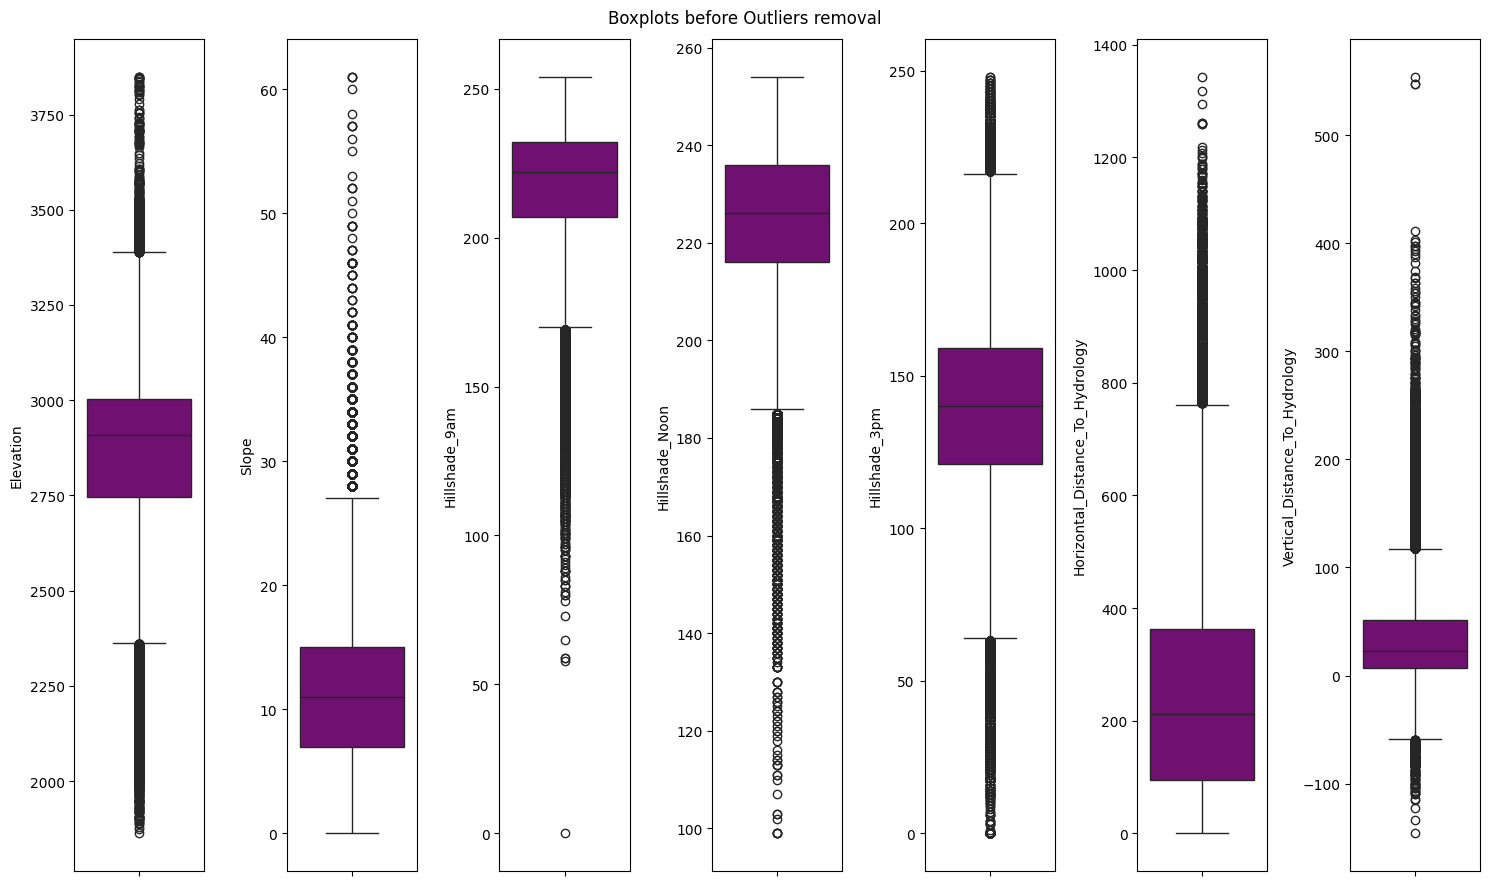

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
continuous1 = ["Elevation", "Slope", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm", "Horizontal_Distance_To_Hydrology", "Vertical_Distance_To_Hydrology"]

# Loop through numerical columns and create boxplots

plt.figure(figsize=(15, 9))
plt.suptitle("Boxplots before Outliers removal")
for i in range(0, len(continuous1)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=df[continuous1[i]],color='purple')
    plt.tight_layout()

In [19]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

In [20]:
for col in continuous1:
    count, lb, ub = detect_outliers_iqr(df, col)
    print(f"{col}: {count} outliers | Range [{lb:.2f}, {ub:.2f}]")

Elevation: 4448 outliers | Range [2361.50, 3389.50]
Slope: 3385 outliers | Range [-5.00, 27.00]
Hillshade_9am: 5242 outliers | Range [169.50, 269.50]
Hillshade_Noon: 3211 outliers | Range [186.00, 266.00]
Hillshade_3pm: 3087 outliers | Range [64.00, 216.00]
Horizontal_Distance_To_Hydrology: 2473 outliers | Range [-305.50, 762.50]
Vertical_Distance_To_Hydrology: 7123 outliers | Range [-59.00, 117.00]


In [21]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,Aspen,1.0,29.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,Aspen,1.0,29.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,1.0,12.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,1.0,30.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,Aspen,1.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,2834.0,88.0,8.0,376.0,44.0,2552.0,232.0,227.0,128.0,1595.0,Lodgepole Pine,1.0,29.0
145886,2832.0,68.0,4.0,390.0,44.0,2522.0,224.0,231.0,142.0,1572.0,Lodgepole Pine,1.0,29.0
145887,2829.0,80.0,7.0,390.0,33.0,2492.0,229.0,228.0,133.0,1550.0,Lodgepole Pine,1.0,29.0
145888,2826.0,121.0,7.0,379.0,30.0,2462.0,232.0,234.0,135.0,1528.0,Lodgepole Pine,1.0,29.0


In [22]:
df_capped = df.copy()

for col in continuous1:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)


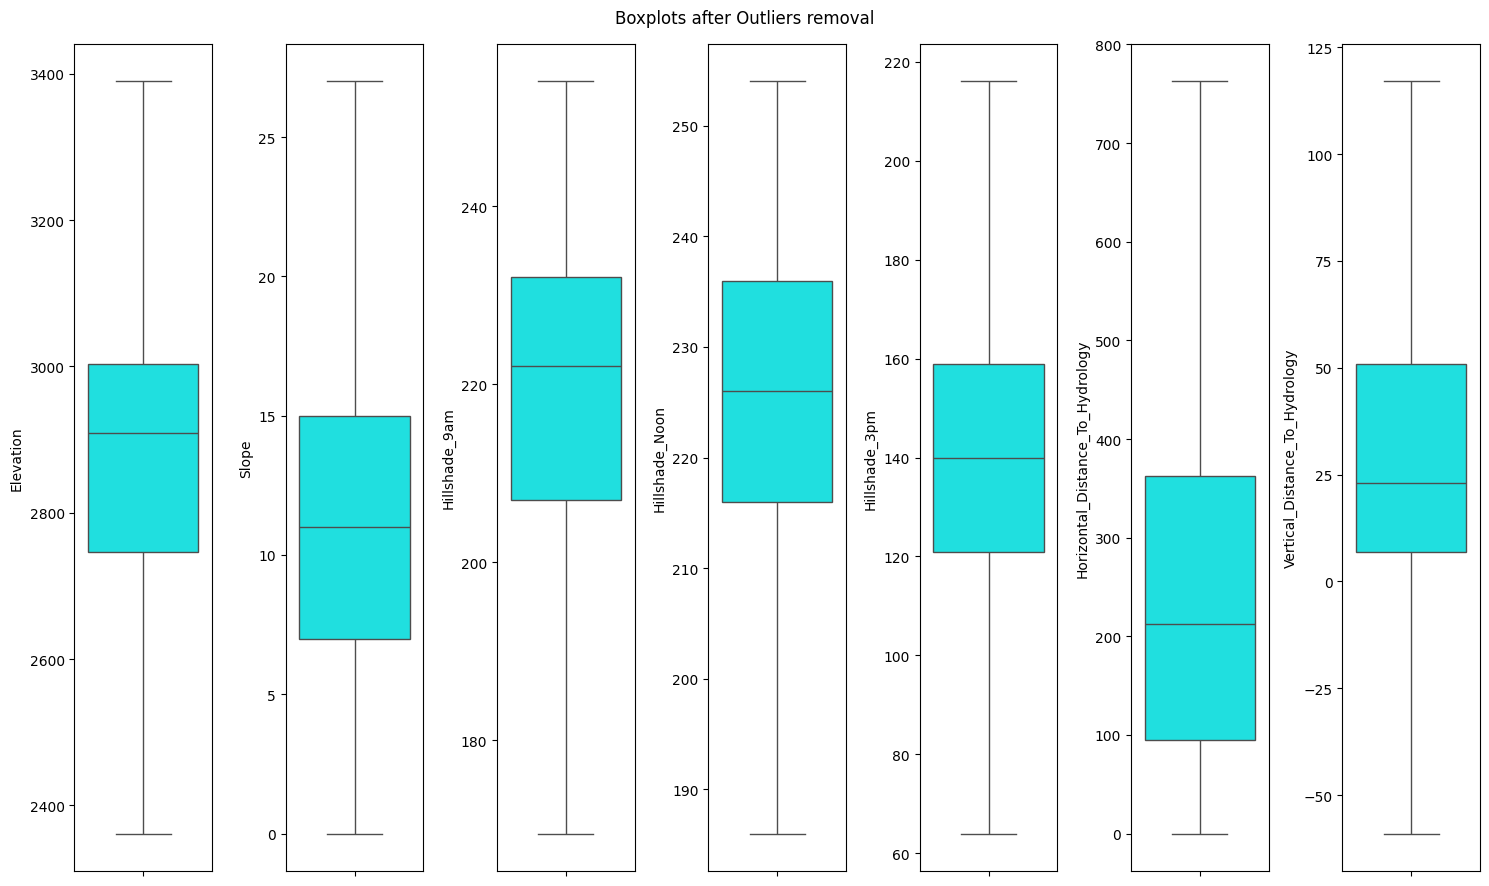

In [23]:
plt.figure(figsize=(15, 9))
plt.suptitle("Boxplots after Outliers removal")
for i in range(0, len(continuous1)):
    plt.subplot(1, 7, i+1)
    sns.boxplot(y=df_capped[continuous1[i]],color='cyan')
    plt.tight_layout()

In [24]:
df_capped.shape

(145890, 13)

In [27]:
from sklearn.preprocessing import PowerTransformer
from scipy import stats

# Yeo-Johnson handles negatives + zeros, unlike Box-Cox
pt = PowerTransformer(method='yeo-johnson', standardize=False)

best_lambdas = {}
for col in continuous:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    if -0.5 < skew < 0.5 and -3 < kurt < 3:
        continue  # already normal enough

    results = []
    for lmbda in [0, 0.5, -0.5, 1, -1, 2, -2]:
        try:
            transformed = stats.boxcox(df[col] + 1e-6, lmbda=lmbda)  # +eps for zeros
            s = pd.Series(transformed).skew()
            k = pd.Series(transformed).kurtosis()
            results.append((abs(s) + abs(k)/3, lmbda, round(s,3), round(k,3)))
        except Exception:
            continue

    best = min(results, key=lambda x: x[0])
    best_lambdas[col] = best[1]
    print(f"{col:45s} → best λ={best[1]:5} | skew={best[2]:6.3f}  kurt={best[3]:7.3f}")

Elevation                                     → best λ=    2 | skew=-0.315  kurt=  1.100
Aspect                                        → best λ=  0.5 | skew= 0.066  kurt= -0.854
Slope                                         → best λ=  0.5 | skew= 0.055  kurt=  0.238
Hillshade_9am                                 → best λ=    2 | skew=-0.872  kurt=  0.883
Hillshade_Noon                                → best λ=    2 | skew=-0.617  kurt=  0.827
Horizontal_Distance_To_Hydrology              → best λ=  0.5 | skew=-0.121  kurt= -0.264
Vertical_Distance_To_Hydrology                → best λ=  0.5 | skew= 0.384  kurt=  0.098


In [28]:
skewness = df[continuous].skew().sort_values(ascending=False)
skewness

,0
Vertical_Distance_To_Hydrology,1.792939
Horizontal_Distance_To_Hydrology,0.984953
Slope,0.943937
Aspect,0.689432
Horizontal_Distance_To_Fire_Points,0.365249
Horizontal_Distance_To_Roadways,-0.058240
Hillshade_3pm,-0.165213
Elevation,-0.664497
Hillshade_Noon,-0.945446
Hillshade_9am,-1.286839


In [29]:
import plotly.express as px
import numpy as np
px.scatter(df, x="Elevation",y="Slope",labels={'x':'First','y':'Second'},title="data_scatter")

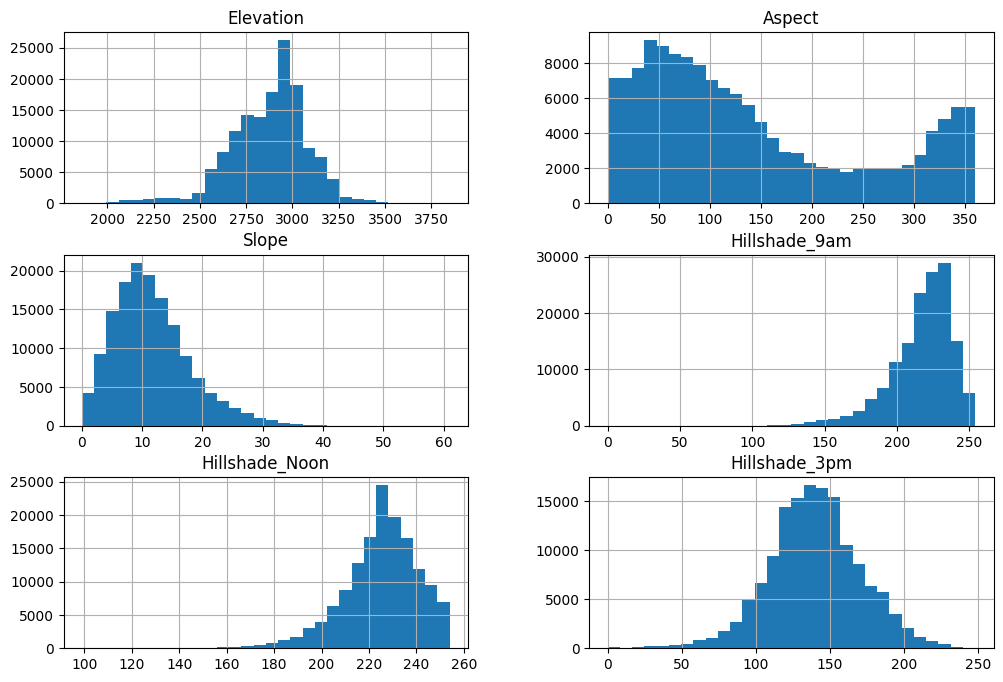

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

df[continuous[:6]].hist(figsize=(12,8), bins=30)
plt.show()

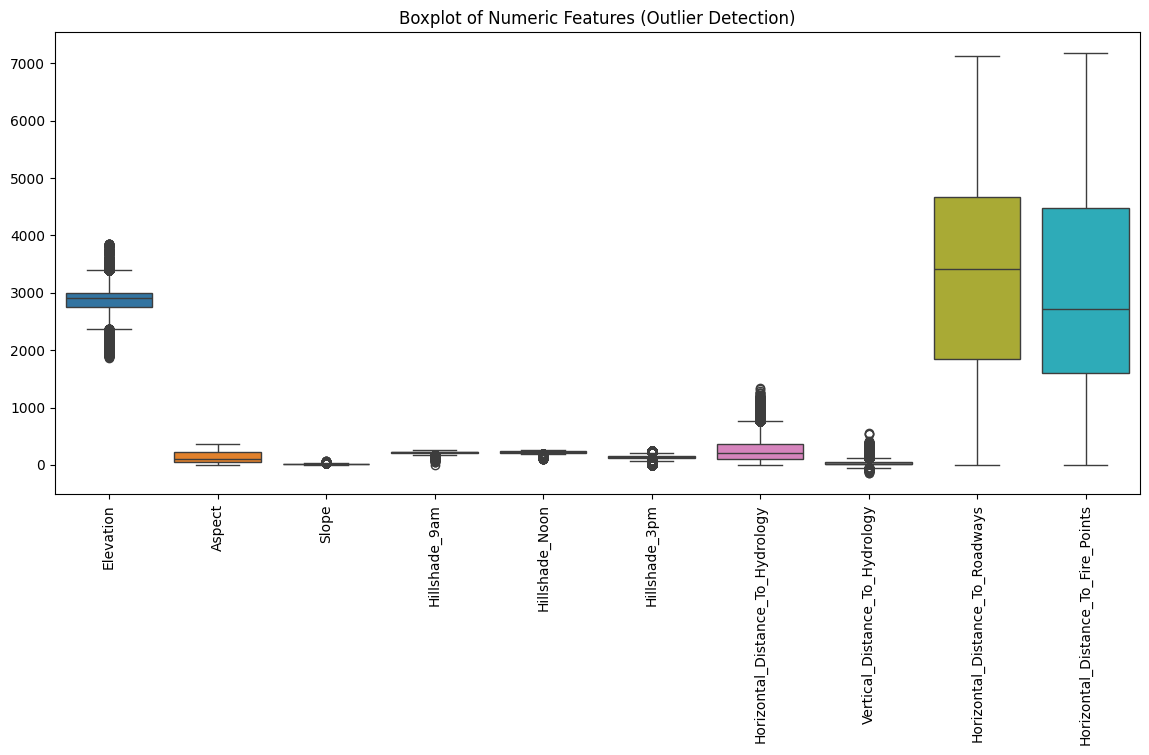

In [31]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[continuous])
plt.xticks(rotation=90)
plt.title("Boxplot of Numeric Features (Outlier Detection)")
plt.show()

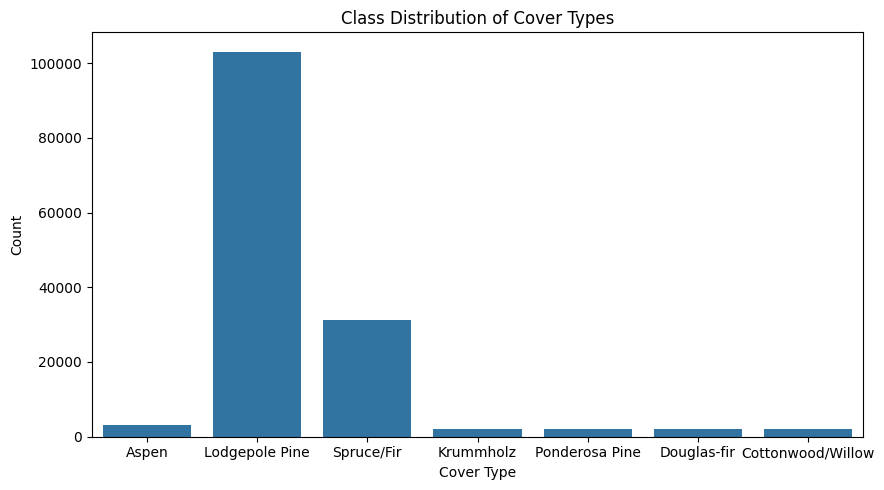

In [32]:
plt.figure(figsize=(9, 5))
sns.countplot(x="Cover_Type", data=df)
plt.title("Class Distribution of Cover Types")
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


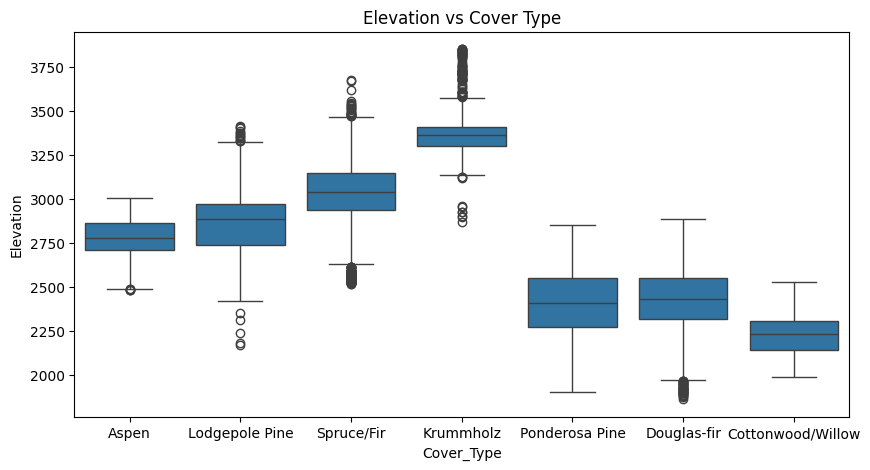

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Cover_Type", y="Elevation", data=df)
plt.title("Elevation vs Cover Type")
plt.show()

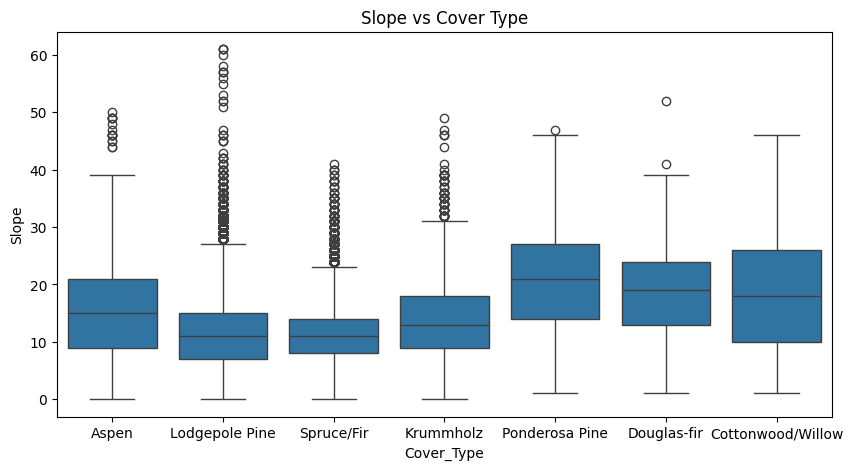

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Cover_Type", y="Slope", data=df)
plt.title("Slope vs Cover Type")
plt.show()

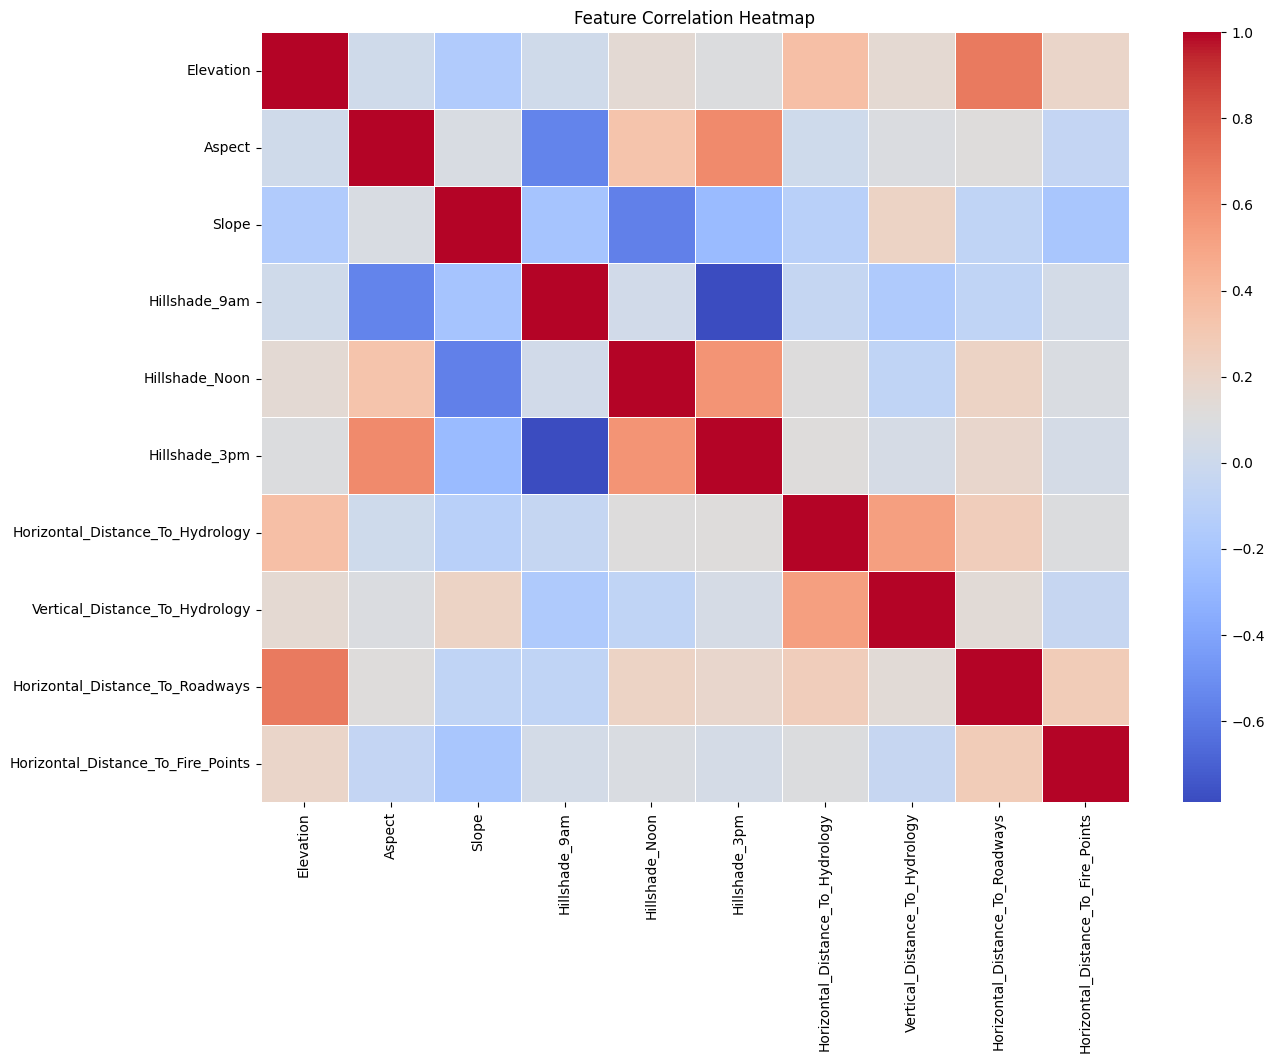

In [35]:
plt.figure(figsize=(14,10))
corr = df[continuous].corr()

sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


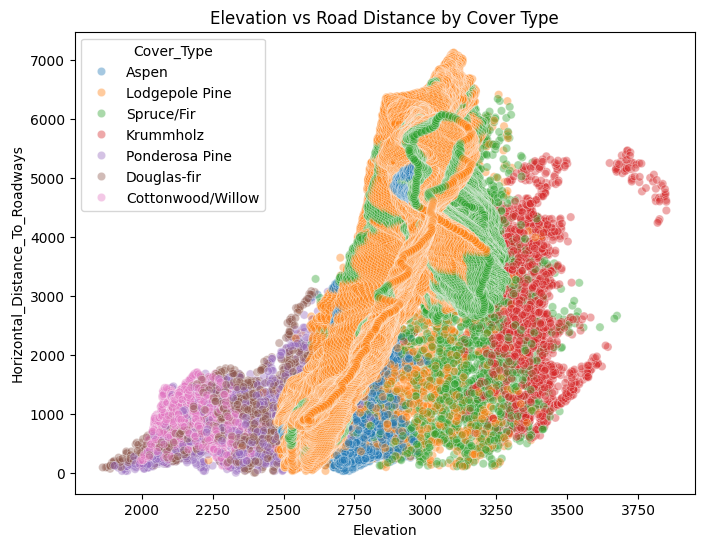

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Elevation",
    y="Horizontal_Distance_To_Roadways",
    hue="Cover_Type",
    data=df,
    alpha=0.4
)
plt.title("Elevation vs Road Distance by Cover Type")
plt.show()

##Feature Engg.

In [37]:
#Feature engineering

skewed_features = [
    "Elevation",
    "Horizontal_Distance_To_Roadways",
    "Horizontal_Distance_To_Fire_Points",
    "Horizontal_Distance_To_Hydrology"
]

for col in skewed_features:
    df[col] = np.log1p(df[col])


In [38]:
df["Elevation_Slope_Interaction"] = df["Elevation"] * df["Slope"]

In [39]:
df["Hillshade_Diff_Morning_Noon"] = df["Hillshade_Noon"] - df["Hillshade_9am"]
df["Hillshade_Diff_Noon_Evening"] = df["Hillshade_Noon"] - df["Hillshade_3pm"]


In [40]:
df["Road_Fire_Ratio"] = (
    df["Horizontal_Distance_To_Roadways"] /
    (df["Horizontal_Distance_To_Fire_Points"] + 1)
)

df["Hydro_Road_Ratio"] = (
    df["Horizontal_Distance_To_Hydrology"] /
    (df["Horizontal_Distance_To_Roadways"] + 1)
)


In [41]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Elevation_Slope_Interaction,Hillshade_Diff_Morning_Noon,Hillshade_Diff_Noon_Evening,Road_Fire_Ratio,Hydro_Road_Ratio
0,7.862112,51.0,3.0,5.556828,0.0,6.236370,221.0,232.0,148.0,8.745125,Aspen,1.0,29.0,23.586337,11.0,84.0,0.639948,0.767903
1,7.859799,56.0,2.0,5.361292,-6.0,5.968708,220.0,235.0,151.0,8.736489,Aspen,1.0,29.0,15.719598,15.0,84.0,0.613025,0.769338
2,7.939159,139.0,9.0,5.594711,65.0,8.064951,234.0,238.0,135.0,8.719644,Lodgepole Pine,1.0,12.0,71.452429,4.0,103.0,0.829758,0.617181
3,7.932362,155.0,18.0,5.493061,118.0,8.036250,238.0,238.0,122.0,8.734238,Lodgepole Pine,1.0,30.0,142.782519,0.0,116.0,0.825565,0.607892
4,7.861727,45.0,2.0,5.036953,-1.0,5.971262,220.0,234.0,150.0,8.727940,Aspen,1.0,29.0,15.723454,14.0,84.0,0.613826,0.722531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145885,7.949797,88.0,8.0,5.932245,44.0,7.845024,232.0,227.0,128.0,7.375256,Lodgepole Pine,1.0,29.0,63.598378,-5.0,99.0,0.936691,0.670687
145886,7.949091,68.0,4.0,5.968708,44.0,7.833204,224.0,231.0,142.0,7.360740,Lodgepole Pine,1.0,29.0,31.796366,7.0,89.0,0.936903,0.675713
145887,7.948032,80.0,7.0,5.968708,33.0,7.821242,229.0,228.0,133.0,7.346655,Lodgepole Pine,1.0,29.0,55.636224,-1.0,95.0,0.937051,0.676629
145888,7.946971,121.0,7.0,5.940171,30.0,7.809135,232.0,234.0,135.0,7.332369,Lodgepole Pine,1.0,29.0,55.628800,2.0,99.0,0.937205,0.674319


In [45]:
X=df.drop(columns=["Cover_Type"])
y=df["Cover_Type"]

##Feature selection

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

rf = RandomForestClassifier(n_estimators=200, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf.fit(X_train, y_train)

# get feature importance
importance = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                               Feature  Importance
0                            Elevation    0.248798
5      Horizontal_Distance_To_Roadways    0.114459
9   Horizontal_Distance_To_Fire_Points    0.098376
15                     Road_Fire_Ratio    0.086505
11                           Soil_Type    0.079234
10                     Wilderness_Area    0.067332
16                    Hydro_Road_Ratio    0.047966
4       Vertical_Distance_To_Hydrology    0.041940
3     Horizontal_Distance_To_Hydrology    0.036735
1                               Aspect    0.027804
7                       Hillshade_Noon    0.025102
12         Elevation_Slope_Interaction    0.024770
14         Hillshade_Diff_Noon_Evening    0.023202
6                        Hillshade_9am    0.021944
8                        Hillshade_3pm    0.020876
13         Hillshade_Diff_Morning_Noon    0.020479
2                                Slope    0.014477


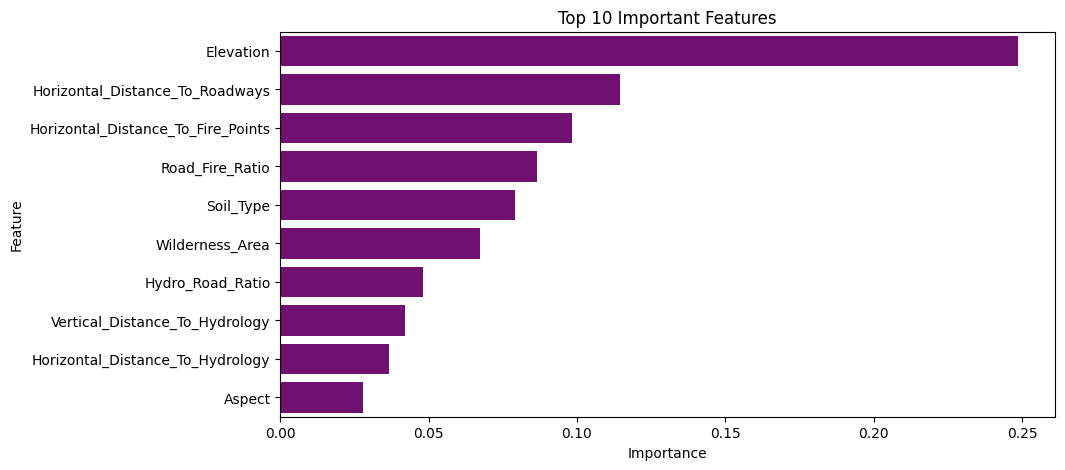

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="purple"
)

plt.title("Top 10 Important Features")
plt.show()

In [50]:
# columns to consider

feature_importance_df['Feature'][:10].tolist()

['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Road_Fire_Ratio',
 'Soil_Type',
 'Wilderness_Area',
 'Hydro_Road_Ratio',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Hydrology',
 'Aspect']

In [51]:
top_10 = ['Elevation',
 'Horizontal_Distance_To_Roadways',
 'Horizontal_Distance_To_Fire_Points',
 'Road_Fire_Ratio',
 'Soil_Type',
 'Wilderness_Area',
 'Hydro_Road_Ratio',
 'Vertical_Distance_To_Hydrology',
 'Horizontal_Distance_To_Hydrology',
 'Aspect', 'Cover_Type']


filtered = df[top_10] # original data

filtered.head()

,Elevation,Horizontal_Distance_To_Roadways,Horizontal_Distance_To_Fire_Points,Road_Fire_Ratio,Soil_Type,Wilderness_Area,Hydro_Road_Ratio,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Hydrology,Aspect,Cover_Type
0,7.862112,6.236370,8.745125,0.639948,29.0,1.0,0.767903,0.0,5.556828,51.0,Aspen
1,7.859799,5.968708,8.736489,0.613025,29.0,1.0,0.769338,-6.0,5.361292,56.0,Aspen
2,7.939159,8.064951,8.719644,0.829758,12.0,1.0,0.617181,65.0,5.594711,139.0,Lodgepole Pine
3,7.932362,8.036250,8.734238,0.825565,30.0,1.0,0.607892,118.0,5.493061,155.0,Lodgepole Pine
4,7.861727,5.971262,8.727940,0.613826,29.0,1.0,0.722531,-1.0,5.036953,45.0,Aspen


In [52]:
X=filtered.drop(columns=["Cover_Type"])
y=filtered["Cover_Type"]

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline   # ← replaces sklearn Pipeline
from imblearn.over_sampling import SMOTE

# ----------------------------------
# 1. Train-test split FIRST
#    (SMOTE will be applied inside pipeline, only on training data)
# ----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------------
# 2. Encode target labels for XGBoost
# ----------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# ----------------------------------
# 3. Feature separation
# ----------------------------------
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

# ----------------------------------
# 4. Preprocessing pipeline
#    Imputer is INSIDE pipeline → NaNs handled before SMOTE
# ----------------------------------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# ----------------------------------
# 5. Models
# ----------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(
                               objective="multi:softprob" if len(np.unique(y)) > 2 else "binary:logistic",
                               eval_metric="mlogloss",
                               use_label_encoder=False,
                               random_state=42
                           )
}

# ----------------------------------
# 6. Train & evaluate using ImbPipeline
#    Order: preprocessor → SMOTE → model
#    SMOTE is skipped automatically at predict time
# ----------------------------------
trained_models = {}
results        = {}

for name, model in models.items():

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),           # Step 1: impute + scale + encode
        ("smote",        SMOTE(random_state=42)), # Step 2: balance classes (train only)
        ("model",        model)                   # Step 3: fit classifier
    ])

    if name == "XGBoost":
        pipeline.fit(X_train, y_train_enc)                        # encoded labels for XGB
        y_pred = le.inverse_transform(pipeline.predict(X_test))   # decode back to original
        results[name] = accuracy_score(y_test, y_pred)
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        results[name] = accuracy_score(y_test, y_pred)

    trained_models[name] = pipeline
    print(f"\n{name}")
    print(classification_report(
        y_test,
        y_pred if name != "XGBoost" else y_pred,
        zero_division=0
    ))

# ----------------------------------
# 7. Results summary
# ----------------------------------
results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])
                .sort_values("Accuracy", ascending=False))

print("\n===== Model Accuracy Comparison =====")
results_df


Logistic Regression
                   precision    recall  f1-score   support

            Aspen       0.12      0.68      0.20       614
Cottonwood/Willow       0.74      0.81      0.78       432
      Douglas-fir       0.64      0.58      0.61       432
        Krummholz       0.65      0.97      0.78       432
   Lodgepole Pine       0.88      0.65      0.74     20614
   Ponderosa Pine       0.61      0.66      0.63       432
       Spruce/Fir       0.48      0.66      0.55      6222

         accuracy                           0.66     29178
        macro avg       0.59      0.72      0.61     29178
     weighted avg       0.76      0.66      0.69     29178


KNN
                   precision    recall  f1-score   support

            Aspen       0.68      0.96      0.79       614
Cottonwood/Willow       0.94      0.94      0.94       432
      Douglas-fir       0.84      0.89      0.86       432
        Krummholz       0.89      0.99      0.94       432
   Lodgepole Pine       0.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[09:10:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.





XGBoost
                   precision    recall  f1-score   support

            Aspen       0.73      0.97      0.83       614
Cottonwood/Willow       0.95      0.97      0.96       432
      Douglas-fir       0.85      0.89      0.87       432
        Krummholz       0.91      0.98      0.94       432
   Lodgepole Pine       0.97      0.93      0.95     20614
   Ponderosa Pine       0.85      0.87      0.86       432
       Spruce/Fir       0.81      0.91      0.86      6222

         accuracy                           0.92     29178
        macro avg       0.87      0.93      0.90     29178
     weighted avg       0.93      0.92      0.92     29178


===== Model Accuracy Comparison =====


,Accuracy
Random Forest,0.966893
Decision Tree,0.944959
KNN,0.927925
XGBoost,0.923230
Logistic Regression,0.655802


Tuning Random Forest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.




Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 6, 'rf__n_estimators': 182}
Best CV Score: 0.9579

Classification Report:

                   precision    recall  f1-score   support

            Aspen       0.87      0.95      0.91       614
Cottonwood/Willow       0.96      0.96      0.96       432
      Douglas-fir       0.89      0.91      0.90       432
        Krummholz       0.93      0.98      0.95       432
   Lodgepole Pine       0.99      0.97      0.98     20614
   Ponderosa Pine       0.86      0.90      0.88       432
       Spruce/Fir       0.93      0.95      0.94      6222

         accuracy                           0.97     29178
        macro avg       0.92      0.95      0.93     29178
     weighted avg       0.97      0.97      0.97     29178



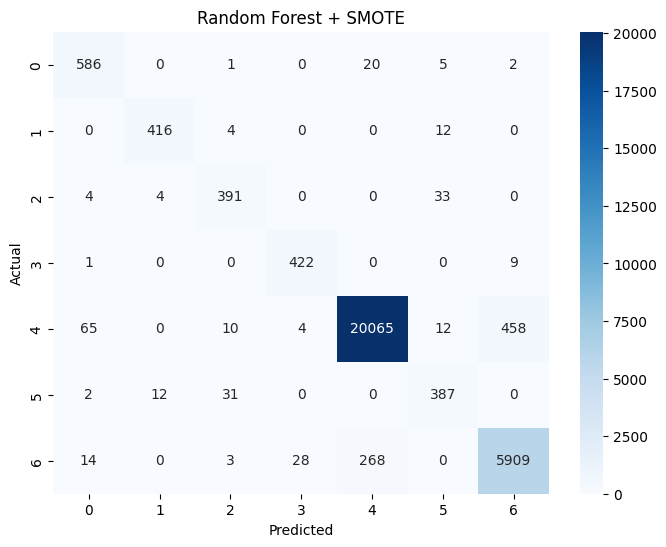

In [54]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import randint
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Pipeline
# -----------------------------
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

# -----------------------------
# 2. Smaller parameter space
# (faster for large datasets)
# -----------------------------
param_dist = {
    "rf__n_estimators": randint(100, 200),
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": randint(2, 10),
    "rf__max_features": ["sqrt"]
}

# -----------------------------
# 3. RandomizedSearchCV
# -----------------------------
search = RandomizedSearchCV(
    rf_pipeline,
    param_dist,
    n_iter=3,           # reduced iterations
    cv=3,
    scoring="f1_weighted",
    n_jobs=2,           # avoid memory crash
    random_state=42,
    verbose=1
)

print("Tuning Random Forest...")
search.fit(X_train, y_train)

print("\nBest Parameters:", search.best_params_)
print("Best CV Score:", round(search.best_score_, 4))

# -----------------------------
# 4. Predictions
# -----------------------------
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

# -----------------------------
# 5. Evaluation
# -----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
import joblib

# best trained pipeline
best_model = search.best_estimator_

# save model
joblib.dump(best_model, "rf_smote_pipeline.pkl")

print("Model saved successfully")

Model saved successfully


In [57]:
!pip install streamlit streamlit_option_menu  # installing streamlit and streamlit_option_menu packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 80.3 MB/s eta 0:00:00


In [2]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# -------------------------------
# Load trained model
# -------------------------------
model = joblib.load("rf_smote_pipeline.pkl")

st.title("🌲 Forest Cover Type Prediction App")

st.write("Enter the environmental features to predict the forest cover type.")

# -------------------------------
# User Inputs
# -------------------------------

Elevation = st.number_input("Elevation", min_value=0)

Horizontal_Distance_To_Roadways = st.number_input(
    "Horizontal Distance To Roadways", min_value=0
)

Horizontal_Distance_To_Fire_Points = st.number_input(
    "Horizontal Distance To Fire Points", min_value=0
)

Vertical_Distance_To_Hydrology = st.number_input(
    "Vertical Distance To Hydrology", min_value=-500, max_value=500
)

Horizontal_Distance_To_Hydrology = st.number_input(
    "Horizontal Distance To Hydrology", min_value=0
)

Aspect = st.number_input("Aspect", min_value=0, max_value=360)

Wilderness_Area = st.selectbox(
    "Wilderness Area",
    [1,2,3,4]
)

Soil_Type = st.number_input("Soil Type", min_value=1, max_value=40)

# -------------------------------
# Feature Engineering
# -------------------------------

Road_Fire_Ratio = Horizontal_Distance_To_Roadways / (Horizontal_Distance_To_Fire_Points + 1)

Hydro_Road_Ratio = Horizontal_Distance_To_Hydrology / (Horizontal_Distance_To_Roadways + 1)

# -------------------------------
# Create dataframe
# -------------------------------

input_data = pd.DataFrame({
    "Elevation":[Elevation],
    "Horizontal_Distance_To_Roadways":[Horizontal_Distance_To_Roadways],
    "Horizontal_Distance_To_Fire_Points":[Horizontal_Distance_To_Fire_Points],
    "Road_Fire_Ratio":[Road_Fire_Ratio],
    "Soil_Type":[Soil_Type],
    "Wilderness_Area":[Wilderness_Area],
    "Hydro_Road_Ratio":[Hydro_Road_Ratio],
    "Vertical_Distance_To_Hydrology":[Vertical_Distance_To_Hydrology],
    "Horizontal_Distance_To_Hydrology":[Horizontal_Distance_To_Hydrology],
    "Aspect":[Aspect]
})

# -------------------------------
# Prediction
# -------------------------------

if st.button("Predict Cover Type"):

    prediction = model.predict(input_data)

    st.success(f"🌳 Predicted Forest Cover Type: {prediction[0]}")


Writing app.py


In [59]:
# @title Setup code
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-03-05 10:20:34--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64 [following]
--2026-03-05 10:20:34--  https://github.com/cloudflare/cloudflared/releases/download/2026.2.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/f9298ca8-89c8-41fe-a51f-e24cb2059878?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-05T10%3A52%3A13Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-05T0

In [4]:
!streamlit run /content/app.py &>/content/logs.txt &

In [5]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

grep: nohup.out: No such file or directory
